# System Engineering Lab — correctie naar echte sessies van 4 uur

Deze notebook corrigeert de administratieve voorstelling van **System Engineering Lab**.

De logica is:

1. twee opeenvolgende roosterblokken op dezelfde dag worden samengevoegd tot één echte sessie van ongeveer vier uur;
2. per sessie en subgroep wordt het hoogste `UserCount` over beide halve blokken genomen;
3. elke vaste wekelijkse sessie krijgt een eigen referentiewaarde:
   - bijvoorbeeld woensdagvoormiddag;
   - woensdagnamiddag;
   - vrijdagvoormiddag;
4. het hoogste waargenomen aantal studenten binnen elk vast sessietype wordt gebruikt als geschat werkelijk verwacht aantal voor dat sessietype;
5. elke week wordt de aanwezigheid vergeleken met het maximum van hetzelfde vaste sessietype.

> Beperking: zonder student-ID's kunnen studenten niet letterlijk gededupliceerd worden. Daarom wordt per sessie en subgroep het maximum van beide halve blokken genomen.


In [25]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Instellingen

In [26]:
server = "localhost\\MSSQLSERVER2019"
database = "DEP2"
driver = "ODBC Driver 17 for SQL Server"

COURSE_NAME = "System Engineering Lab"
PROGRAM_FILTER = "PBA-TIN%"
SEMESTER_NUMBER = 2
START_DATE = "2026-02-01"
END_DATE = "2026-06-30"

MAX_BREAK_MINUTES = 30
MIN_SESSION_DURATION_MINUTES = 210
MAX_SESSION_DURATION_MINUTES = 300

engine = sa.create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    f"?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)


## 2. Data ophalen

In [27]:
query = '''
SELECT
    fl.LectureID,
    fl.DateKey,
    fl.FromTimeKey,
    fl.UntilTimeKey,
    fl.ClassKey,
    fl.SubgroupKey,
    fl.RoomKey,
    fl.UserCount,
    fl.TotalStudents,
    fl.AttendanceRate,

    d.FullDate,
    d.NumberSemester,

    tf.Hour AS FromHour,
    tf.Minutes AS FromMinutes,
    tf.Seconds AS FromSeconds,

    tu.Hour AS UntilHour,
    tu.Minutes AS UntilMinutes,
    tu.Seconds AS UntilSeconds,

    c.ClassCode,
    c.ClassName,
    c.ClassProgramStage,

    sg.SubgroupCode,
    sg.ProgramName,

    r.Code AS RoomCode,
    r.RoomName,
    r.Capacity AS RoomCapacity,

    a.ActivityDomain,
    a.ActivityGroup,
    a.IsCourse,
    a.IsPractical
FROM FactLecture fl
JOIN DimDate d ON fl.DateKey = d.DateKey
JOIN DimTime tf ON fl.FromTimeKey = tf.TimeKey
JOIN DimTime tu ON fl.UntilTimeKey = tu.TimeKey
JOIN DimClass c ON fl.ClassKey = c.ClassKey
JOIN DimSubgroup sg ON fl.SubgroupKey = sg.SubgroupKey
JOIN DimRoom r ON fl.RoomKey = r.RoomKey
JOIN DimActivity a ON fl.ActivityKey = a.ActivityKey
WHERE sg.ProgramName LIKE ?
  AND c.ClassName = ?
  AND d.NumberSemester = ?
  AND d.FullDate BETWEEN ? AND ?
ORDER BY d.FullDate, tf.Hour, tf.Minutes, r.Code, sg.SubgroupCode;
'''

raw = pd.read_sql(
    query,
    engine,
    params=(
        PROGRAM_FILTER,
        COURSE_NAME,
        SEMESTER_NUMBER,
        START_DATE,
        END_DATE,
    ),
)

raw["FullDate"] = pd.to_datetime(raw["FullDate"])

print(f"Factrijen: {len(raw):,}")
print(f"Unieke LectureID's: {raw['LectureID'].nunique():,}")
print(f"Lesdagen: {raw['FullDate'].nunique():,}")
print(f"Lokalen: {raw['RoomCode'].nunique():,}")
print(f"Subgroepen: {raw['SubgroupCode'].nunique():,}")

raw.head(20)


Factrijen: 539
Unieke LectureID's: 77
Lesdagen: 36
Lokalen: 6
Subgroepen: 8


,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,UserCount,TotalStudents,AttendanceRate,FullDate,NumberSemester,FromHour,FromMinutes,FromSeconds,UntilHour,UntilMinutes,UntilSeconds,ClassCode,ClassName,ClassProgramStage,SubgroupCode,ProgramName,RoomCode,RoomName,RoomCapacity,ActivityDomain,ActivityGroup,IsCourse,IsPractical
0,424591,20260211,81500,101500,4020,5938937,2968,0,32,0.0000,2026-02-11,2,8,15,0,10,15,0,193579,System Engineering Lab,1,PBA-TIN-TI/1A,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
1,424591,20260211,81500,101500,4020,5829023,2968,0,27,0.0000,2026-02-11,2,8,15,0,10,15,0,193579,System Engineering Lab,1,PBA-TIN-TI/1B,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
2,424591,20260211,81500,101500,4020,5829227,2968,0,33,0.0000,2026-02-11,2,8,15,0,10,15,0,193579,System Engineering Lab,1,PBA-TIN-TI/1C,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
3,424591,20260211,81500,101500,4020,5997470,2968,1,28,0.0357,2026-02-11,2,8,15,0,10,15,0,193579,System Engineering Lab,1,PBA-TIN-TI/1D,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
4,424591,20260211,81500,101500,4020,5997674,2968,0,27,0.0000,2026-02-11,2,8,15,0,10,15,0,193579,System Engineering Lab,1,PBA-TIN-TI/1E,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
5,424591,20260211,81500,101500,4020,5997878,2968,3,35,0.0857,2026-02-11,2,8,15,0,10,15,0,193579,System Engineering Lab,1,PBA-TIN-TI/1F,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
6,424591,20260211,81500,101500,4020,5879360,2968,0,27,0.0000,2026-02-11,2,8,15,0,10,15,0,193579,System Engineering Lab,1,PBA-TIN-TI/1G,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
7,424606,20260211,103000,123000,4020,5938937,2968,1,32,0.0312,2026-02-11,2,10,30,0,12,30,0,193579,System Engineering Lab,1,PBA-TIN-TI/1A,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
8,424606,20260211,103000,123000,4020,5829023,2968,12,27,0.4444,2026-02-11,2,10,30,0,12,30,0,193579,System Engineering Lab,1,PBA-TIN-TI/1B,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False
9,424606,20260211,103000,123000,4020,5829227,2968,6,33,0.1818,2026-02-11,2,10,30,0,12,30,0,193579,System Engineering Lab,1,PBA-TIN-TI/1C,PBA-TIN-TI,01.02.140.037,GSCHB.4.037,72,Course,Lecture,True,False


## 3. Exacte begin- en eindtijd maken

In [28]:
raw["StartDateTime"] = (
    raw["FullDate"]
    + pd.to_timedelta(raw["FromHour"], unit="h")
    + pd.to_timedelta(raw["FromMinutes"], unit="m")
    + pd.to_timedelta(raw["FromSeconds"], unit="s")
)

raw["EndDateTime"] = (
    raw["FullDate"]
    + pd.to_timedelta(raw["UntilHour"], unit="h")
    + pd.to_timedelta(raw["UntilMinutes"], unit="m")
    + pd.to_timedelta(raw["UntilSeconds"], unit="s")
)

raw["BlockDurationMinutes"] = (
    raw["EndDateTime"] - raw["StartDateTime"]
).dt.total_seconds() / 60

raw[[
    "FullDate", "LectureID", "StartDateTime", "EndDateTime",
    "RoomCode", "SubgroupCode", "UserCount", "TotalStudents"
]].head(20)


,FullDate,LectureID,StartDateTime,EndDateTime,RoomCode,SubgroupCode,UserCount,TotalStudents
0,2026-02-11,424591,2026-02-11 08:15:00,2026-02-11 10:15:00,01.02.140.037,PBA-TIN-TI/1A,0,32
1,2026-02-11,424591,2026-02-11 08:15:00,2026-02-11 10:15:00,01.02.140.037,PBA-TIN-TI/1B,0,27
2,2026-02-11,424591,2026-02-11 08:15:00,2026-02-11 10:15:00,01.02.140.037,PBA-TIN-TI/1C,0,33
3,2026-02-11,424591,2026-02-11 08:15:00,2026-02-11 10:15:00,01.02.140.037,PBA-TIN-TI/1D,1,28
4,2026-02-11,424591,2026-02-11 08:15:00,2026-02-11 10:15:00,01.02.140.037,PBA-TIN-TI/1E,0,27
5,2026-02-11,424591,2026-02-11 08:15:00,2026-02-11 10:15:00,01.02.140.037,PBA-TIN-TI/1F,3,35
6,2026-02-11,424591,2026-02-11 08:15:00,2026-02-11 10:15:00,01.02.140.037,PBA-TIN-TI/1G,0,27
7,2026-02-11,424606,2026-02-11 10:30:00,2026-02-11 12:30:00,01.02.140.037,PBA-TIN-TI/1A,1,32
8,2026-02-11,424606,2026-02-11 10:30:00,2026-02-11 12:30:00,01.02.140.037,PBA-TIN-TI/1B,12,27
9,2026-02-11,424606,2026-02-11 10:30:00,2026-02-11 12:30:00,01.02.140.037,PBA-TIN-TI/1C,6,33


## 4. Unieke tijdsblokken per dag bepalen

In [29]:
time_blocks = (
    raw[["FullDate", "StartDateTime", "EndDateTime"]]
    .drop_duplicates()
    .reset_index(drop=True)
    .sort_values(["FullDate", "StartDateTime", "EndDateTime"])
)

print(time_blocks.columns.tolist())
time_blocks.head(20)


['FullDate', 'StartDateTime', 'EndDateTime']


,FullDate,StartDateTime,EndDateTime
0,2026-02-11,2026-02-11 08:15:00,2026-02-11 10:15:00
1,2026-02-11,2026-02-11 10:30:00,2026-02-11 12:30:00
2,2026-02-12,2026-02-12 13:30:00,2026-02-12 15:30:00
3,2026-02-12,2026-02-12 15:45:00,2026-02-12 17:45:00
4,2026-02-13,2026-02-13 08:15:00,2026-02-13 10:15:00
5,2026-02-13,2026-02-13 10:30:00,2026-02-13 12:30:00
6,2026-02-18,2026-02-18 08:15:00,2026-02-18 10:15:00
7,2026-02-18,2026-02-18 10:30:00,2026-02-18 12:30:00
8,2026-02-19,2026-02-19 13:30:00,2026-02-19 15:30:00
9,2026-02-19,2026-02-19 15:45:00,2026-02-19 17:45:00


## 5. Opeenvolgende blokken samenvoegen tot sessies

In [30]:
def assign_session_ids(day_blocks):
    day_blocks = day_blocks.sort_values(
        ["StartDateTime", "EndDateTime"]
    ).copy()

    session_number = 0
    current_start = None
    current_end = None
    assigned = []

    for row in day_blocks.itertuples(index=False):
        if current_start is None:
            session_number += 1
            current_start = row.StartDateTime
            current_end = row.EndDateTime
        else:
            gap_minutes = (
                row.StartDateTime - current_end
            ).total_seconds() / 60

            proposed_end = max(current_end, row.EndDateTime)

            proposed_duration = (
                proposed_end - current_start
            ).total_seconds() / 60

            if (
                gap_minutes <= MAX_BREAK_MINUTES
                and proposed_duration <= MAX_SESSION_DURATION_MINUTES
            ):
                current_end = proposed_end
            else:
                session_number += 1
                current_start = row.StartDateTime
                current_end = row.EndDateTime

        assigned.append(session_number)

    day_blocks["SessionNumberOnDay"] = assigned
    return day_blocks


processed_days = []

for full_date, day_blocks in time_blocks.groupby(
    "FullDate",
    sort=True
):
    processed_days.append(
        assign_session_ids(day_blocks)
    )

time_blocks = pd.concat(
    processed_days,
    ignore_index=True
)

time_blocks["SessionID"] = (
    time_blocks["FullDate"].dt.strftime("%Y%m%d")
    + "_"
    + time_blocks["SessionNumberOnDay"].astype(str)
)

time_blocks.head(30)


,FullDate,StartDateTime,EndDateTime,SessionNumberOnDay,SessionID
0,2026-02-11,2026-02-11 08:15:00,2026-02-11 10:15:00,1,20260211_1
1,2026-02-11,2026-02-11 10:30:00,2026-02-11 12:30:00,1,20260211_1
2,2026-02-12,2026-02-12 13:30:00,2026-02-12 15:30:00,1,20260212_1
3,2026-02-12,2026-02-12 15:45:00,2026-02-12 17:45:00,1,20260212_1
4,2026-02-13,2026-02-13 08:15:00,2026-02-13 10:15:00,1,20260213_1
5,2026-02-13,2026-02-13 10:30:00,2026-02-13 12:30:00,1,20260213_1
6,2026-02-18,2026-02-18 08:15:00,2026-02-18 10:15:00,1,20260218_1
7,2026-02-18,2026-02-18 10:30:00,2026-02-18 12:30:00,1,20260218_1
8,2026-02-19,2026-02-19 13:30:00,2026-02-19 15:30:00,1,20260219_1
9,2026-02-19,2026-02-19 15:45:00,2026-02-19 17:45:00,1,20260219_1


## 6. Gevormde sessies controleren

In [31]:
session_schedule = (
    time_blocks.groupby(["FullDate", "SessionID"])
    .agg(
        SessionStart=("StartDateTime", "min"),
        SessionEnd=("EndDateTime", "max"),
        NumberOfTimeBlocks=("StartDateTime", "size"),
    )
    .reset_index()
)

session_schedule["SessionDurationMinutes"] = (
    session_schedule["SessionEnd"]
    - session_schedule["SessionStart"]
).dt.total_seconds() / 60

session_schedule["LooksLikeFourHourSession"] = (
    session_schedule["SessionDurationMinutes"]
    .between(
        MIN_SESSION_DURATION_MINUTES,
        MAX_SESSION_DURATION_MINUTES,
    )
)

session_schedule.sort_values(
    ["FullDate", "SessionStart"]
)


,FullDate,SessionID,SessionStart,SessionEnd,NumberOfTimeBlocks,SessionDurationMinutes,LooksLikeFourHourSession
0,2026-02-11,20260211_1,2026-02-11 08:15:00,2026-02-11 12:30:00,2,255.0000,True
1,2026-02-12,20260212_1,2026-02-12 13:30:00,2026-02-12 17:45:00,2,255.0000,True
2,2026-02-13,20260213_1,2026-02-13 08:15:00,2026-02-13 12:30:00,2,255.0000,True
3,2026-02-18,20260218_1,2026-02-18 08:15:00,2026-02-18 12:30:00,2,255.0000,True
4,2026-02-19,20260219_1,2026-02-19 13:30:00,2026-02-19 17:45:00,2,255.0000,True
5,2026-02-20,20260220_1,2026-02-20 08:15:00,2026-02-20 12:30:00,2,255.0000,True
6,2026-02-25,20260225_1,2026-02-25 08:15:00,2026-02-25 12:30:00,2,255.0000,True
7,2026-02-26,20260226_1,2026-02-26 13:30:00,2026-02-26 17:45:00,2,255.0000,True
8,2026-02-27,20260227_1,2026-02-27 08:15:00,2026-02-27 12:30:00,2,255.0000,True
9,2026-03-04,20260304_1,2026-03-04 08:15:00,2026-03-04 12:30:00,2,255.0000,True


In [32]:
display(
    session_schedule["NumberOfTimeBlocks"]
    .value_counts()
    .sort_index()
    .rename_axis("Aantal tijdsblokken")
    .to_frame("Aantal sessies")
)

display(session_schedule["SessionDurationMinutes"].describe())


,Aantal sessies
Aantal tijdsblokken,
2,36


count    36.0000
mean    255.0000
std       0.0000
min     255.0000
25%     255.0000
50%     255.0000
75%     255.0000
max     255.0000
Name: SessionDurationMinutes, dtype: float64

## 7. Sessie-ID terugkoppelen naar alle factrijen

In [33]:
raw = raw.merge(
    time_blocks[[
        "FullDate",
        "StartDateTime",
        "EndDateTime",
        "SessionID",
    ]],
    on=[
        "FullDate",
        "StartDateTime",
        "EndDateTime",
    ],
    how="left",
    validate="many_to_one",
)

assert raw["SessionID"].notna().all()


## 8. Per sessie en subgroep één aanwezigheidsaantal bepalen

Per subgroep nemen we het hoogste `UserCount` over beide halve blokken. Zo tellen we dezelfde studenten niet automatisch twee keer.


In [34]:
session_subgroup = (
    raw.groupby([
        "FullDate",
        "SessionID",
        "SubgroupCode",
    ])
    .agg(
        EstimatedUniquePresent=("UserCount", "max"),
        AdministrativeStudents=("TotalStudents", "max"),
        NumberOfRows=("LectureID", "size"),
        NumberOfLectureIDs=("LectureID", "nunique"),
        NumberOfBlocks=("StartDateTime", "nunique"),
        NumberOfRooms=("RoomCode", "nunique"),
        Rooms=("RoomCode", lambda x: ", ".join(sorted(set(map(str, x))))),
        MinBlockCount=("UserCount", "min"),
        MaxBlockCount=("UserCount", "max"),
    )
    .reset_index()
)

session_subgroup.head(30)


,FullDate,SessionID,SubgroupCode,EstimatedUniquePresent,AdministrativeStudents,NumberOfRows,NumberOfLectureIDs,NumberOfBlocks,NumberOfRooms,Rooms,MinBlockCount,MaxBlockCount
0,2026-02-11,20260211_1,PBA-TIN-TI/1A,1,32,2,2,2,1,01.02.140.037,0,1
1,2026-02-11,20260211_1,PBA-TIN-TI/1B,12,27,2,2,2,1,01.02.140.037,0,12
2,2026-02-11,20260211_1,PBA-TIN-TI/1C,6,33,2,2,2,1,01.02.140.037,0,6
3,2026-02-11,20260211_1,PBA-TIN-TI/1D,5,28,2,2,2,1,01.02.140.037,1,5
4,2026-02-11,20260211_1,PBA-TIN-TI/1E,0,27,2,2,2,1,01.02.140.037,0,0
5,2026-02-11,20260211_1,PBA-TIN-TI/1F,3,35,2,2,2,1,01.02.140.037,1,3
6,2026-02-11,20260211_1,PBA-TIN-TI/1G,12,27,2,2,2,1,01.02.140.037,0,12
7,2026-02-12,20260212_1,PBA-TIN-TI/1A,1,32,2,2,2,1,01.02.120.011,0,1
8,2026-02-12,20260212_1,PBA-TIN-TI/1B,0,27,2,2,2,1,01.02.120.011,0,0
9,2026-02-12,20260212_1,PBA-TIN-TI/1D,0,28,2,2,2,1,01.02.120.011,0,0


## 9. Totaal aantal aanwezigen per echte sessie

In [35]:
session_attendance = (
    session_subgroup.groupby([
        "FullDate",
        "SessionID",
    ])
    .agg(
        EstimatedPresentStudents=("EstimatedUniquePresent", "sum"),
        AdministrativeExpectedStudents=("AdministrativeStudents", "sum"),
        NumberOfSubgroups=("SubgroupCode", "nunique"),
    )
    .reset_index()
)

rooms_per_session = (
    raw.groupby(["FullDate", "SessionID"])["RoomCode"]
    .agg(
        NumberOfDistinctRooms="nunique",
        Rooms=lambda x: ", ".join(sorted(set(map(str, x)))),
    )
    .reset_index()
)

session_attendance = (
    session_attendance
    .merge(
        session_schedule,
        on=["FullDate", "SessionID"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        rooms_per_session,
        on=["FullDate", "SessionID"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["FullDate", "SessionStart"])
    .reset_index(drop=True)
)

session_attendance


,FullDate,SessionID,EstimatedPresentStudents,AdministrativeExpectedStudents,NumberOfSubgroups,SessionStart,SessionEnd,NumberOfTimeBlocks,SessionDurationMinutes,LooksLikeFourHourSession,NumberOfDistinctRooms,Rooms
0,2026-02-11,20260211_1,39,209,7,2026-02-11 08:15:00,2026-02-11 12:30:00,2,255.0000,True,1,01.02.140.037
1,2026-02-12,20260212_1,3,206,7,2026-02-12 13:30:00,2026-02-12 17:45:00,2,255.0000,True,1,01.02.120.011
2,2026-02-13,20260213_1,15,204,7,2026-02-13 08:15:00,2026-02-13 12:30:00,2,255.0000,True,1,01.02.110.014
3,2026-02-18,20260218_1,12,209,7,2026-02-18 08:15:00,2026-02-18 12:30:00,2,255.0000,True,1,01.02.140.037
4,2026-02-19,20260219_1,5,206,7,2026-02-19 13:30:00,2026-02-19 17:45:00,2,255.0000,True,1,01.02.120.011
5,2026-02-20,20260220_1,86,204,7,2026-02-20 08:15:00,2026-02-20 12:30:00,2,255.0000,True,1,01.02.110.014
6,2026-02-25,20260225_1,144,209,7,2026-02-25 08:15:00,2026-02-25 12:30:00,2,255.0000,True,1,01.02.140.037
7,2026-02-26,20260226_1,126,206,7,2026-02-26 13:30:00,2026-02-26 17:45:00,2,255.0000,True,1,01.02.120.011
8,2026-02-27,20260227_1,92,204,7,2026-02-27 08:15:00,2026-02-27 12:30:00,2,255.0000,True,1,01.02.120.010
9,2026-03-04,20260304_1,136,209,7,2026-03-04 08:15:00,2026-03-04 12:30:00,2,255.0000,True,1,01.02.140.037


## 10. Alleen geldige 4-uursessies behouden

In [36]:
valid_sessions = session_attendance[
    session_attendance["LooksLikeFourHourSession"]
].copy()

invalid_sessions = session_attendance[
    ~session_attendance["LooksLikeFourHourSession"]
].copy()

print(f"Geldige 4-uursessies: {len(valid_sessions)}")
print(f"Afwijkende sessies: {len(invalid_sessions)}")

if len(invalid_sessions):
    display(
        invalid_sessions[[
            "FullDate",
            "SessionStart",
            "SessionEnd",
            "NumberOfTimeBlocks",
            "SessionDurationMinutes",
            "EstimatedPresentStudents",
            "Rooms",
        ]]
    )


Geldige 4-uursessies: 36
Afwijkende sessies: 0


## 11. Vast wekelijks sessietype bepalen

Elke vaste sessie krijgt een eigen sleutel op basis van:

- weekdag;
- startuur;
- einduur.

Voorbeelden:

- Wednesday 08:15–12:30
- Wednesday 13:15–17:30
- Friday 08:15–12:30


In [37]:
valid_sessions["WeekdayNumber"] = (
    valid_sessions["FullDate"].dt.weekday
)

valid_sessions["WeekdayName"] = (
    valid_sessions["FullDate"].dt.day_name()
)

valid_sessions["SessionStartTime"] = (
    valid_sessions["SessionStart"].dt.strftime("%H:%M")
)

valid_sessions["SessionEndTime"] = (
    valid_sessions["SessionEnd"].dt.strftime("%H:%M")
)

valid_sessions["SessionSlot"] = (
    valid_sessions["WeekdayName"]
    + " "
    + valid_sessions["SessionStartTime"]
    + "-"
    + valid_sessions["SessionEndTime"]
)

valid_sessions.sort_values(
    [
        "WeekdayNumber",
        "SessionStartTime",
        "FullDate",
    ]
)[[
    "FullDate",
    "WeekdayName",
    "SessionStartTime",
    "SessionEndTime",
    "SessionSlot",
    "EstimatedPresentStudents",
    "NumberOfDistinctRooms",
    "Rooms",
]]

,FullDate,WeekdayName,SessionStartTime,SessionEndTime,SessionSlot,EstimatedPresentStudents,NumberOfDistinctRooms,Rooms
0,2026-02-11,Wednesday,08:15,12:30,Wednesday 08:15-12:30,39,1,01.02.140.037
3,2026-02-18,Wednesday,08:15,12:30,Wednesday 08:15-12:30,12,1,01.02.140.037
6,2026-02-25,Wednesday,08:15,12:30,Wednesday 08:15-12:30,144,1,01.02.140.037
9,2026-03-04,Wednesday,08:15,12:30,Wednesday 08:15-12:30,136,1,01.02.140.037
12,2026-03-11,Wednesday,08:15,12:30,Wednesday 08:15-12:30,119,1,01.02.140.037
15,2026-03-18,Wednesday,08:15,12:30,Wednesday 08:15-12:30,134,1,01.02.140.037
18,2026-03-25,Wednesday,08:15,12:30,Wednesday 08:15-12:30,128,1,01.02.140.037
21,2026-04-01,Wednesday,08:15,12:30,Wednesday 08:15-12:30,97,1,01.02.140.037
24,2026-04-22,Wednesday,08:15,12:30,Wednesday 08:15-12:30,96,1,01.02.140.037
27,2026-04-29,Wednesday,08:15,12:30,Wednesday 08:15-12:30,49,1,01.02.140.037


## 12. Verwacht aantal studenten per vast sessietype bepalen

Voor elk vast sessietype nemen we het hoogste waargenomen aantal studenten van het semester.

Daarnaast tonen we:

- het 95e percentiel;
- het aantal geobserveerde sessies;
- de datum waarop het maximum voorkwam.


In [38]:
slot_expected = (
    valid_sessions
    .groupby([
        "WeekdayNumber",
        "WeekdayName",
        "SessionStartTime",
        "SessionEndTime",
        "SessionSlot",
    ], as_index=False)
    .agg(
        ExpectedStudentsForSlot=(
            "EstimatedPresentStudents",
            "max",
        ),
        P95StudentsForSlot=(
            "EstimatedPresentStudents",
            lambda x: x.quantile(0.95),
        ),
        NumberOfObservedSessions=(
            "SessionID",
            "nunique",
        ),
    )
    .sort_values([
        "WeekdayNumber",
        "SessionStartTime",
    ])
)

slot_expected


,WeekdayNumber,WeekdayName,SessionStartTime,SessionEndTime,SessionSlot,ExpectedStudentsForSlot,P95StudentsForSlot,NumberOfObservedSessions
0,2,Wednesday,08:15,12:30,Wednesday 08:15-12:30,144,139.2000,13
1,3,Thursday,13:30,17:45,Thursday 13:30-17:45,126,124.9000,12
2,4,Friday,08:15,12:30,Friday 08:15-12:30,94,93.0000,11


In [39]:
max_dates_per_slot = (
    valid_sessions.loc[
        valid_sessions.groupby("SessionSlot")[
            "EstimatedPresentStudents"
        ].idxmax(),
        [
            "SessionSlot",
            "FullDate",
            "SessionStart",
            "SessionEnd",
            "EstimatedPresentStudents",
            "Rooms",
        ],
    ]
    .rename(columns={
        "FullDate": "DateOfMaximum",
        "EstimatedPresentStudents": "MaximumObservedStudents",
    })
    .sort_values("SessionSlot")
)

max_dates_per_slot


,SessionSlot,DateOfMaximum,SessionStart,SessionEnd,MaximumObservedStudents,Rooms
11,Friday 08:15-12:30,2026-03-06,2026-03-06 08:15:00,2026-03-06 12:30:00,94,01.02.120.010
7,Thursday 13:30-17:45,2026-02-26,2026-02-26 13:30:00,2026-02-26 17:45:00,126,01.02.120.011
6,Wednesday 08:15-12:30,2026-02-25,2026-02-25 08:15:00,2026-02-25 12:30:00,144,01.02.140.037


## 13. Referentiewaarde terugkoppelen naar elke sessie

In [40]:
valid_sessions = valid_sessions.merge(
    slot_expected[[
        "SessionSlot",
        "ExpectedStudentsForSlot",
        "P95StudentsForSlot",
        "NumberOfObservedSessions",
    ]],
    on="SessionSlot",
    how="left",
    validate="many_to_one",
)

valid_sessions["CorrectedAttendanceRate"] = (
    valid_sessions["EstimatedPresentStudents"]
    / valid_sessions["ExpectedStudentsForSlot"]
)

valid_sessions["CorrectedAttendanceRateCapped"] = (
    valid_sessions["CorrectedAttendanceRate"].clip(upper=1)
)

valid_sessions["AdministrativeAttendanceRate"] = (
    valid_sessions["EstimatedPresentStudents"]
    / valid_sessions["AdministrativeExpectedStudents"]
)

valid_sessions.sort_values(
    [
        "WeekdayNumber",
        "SessionStartTime",
        "FullDate",
    ]
)[[
    "FullDate",
    "WeekdayName",
    "SessionStartTime",
    "SessionEndTime",
    "SessionSlot",
    "EstimatedPresentStudents",
    "ExpectedStudentsForSlot",
    "CorrectedAttendanceRate",
    "AdministrativeExpectedStudents",
    "AdministrativeAttendanceRate",
    "NumberOfDistinctRooms",
    "Rooms",
]]

,FullDate,WeekdayName,SessionStartTime,SessionEndTime,SessionSlot,EstimatedPresentStudents,ExpectedStudentsForSlot,CorrectedAttendanceRate,AdministrativeExpectedStudents,AdministrativeAttendanceRate,NumberOfDistinctRooms,Rooms
0,2026-02-11,Wednesday,08:15,12:30,Wednesday 08:15-12:30,39,144,0.2708,209,0.1866,1,01.02.140.037
3,2026-02-18,Wednesday,08:15,12:30,Wednesday 08:15-12:30,12,144,0.0833,209,0.0574,1,01.02.140.037
6,2026-02-25,Wednesday,08:15,12:30,Wednesday 08:15-12:30,144,144,1.0000,209,0.6890,1,01.02.140.037
9,2026-03-04,Wednesday,08:15,12:30,Wednesday 08:15-12:30,136,144,0.9444,209,0.6507,1,01.02.140.037
12,2026-03-11,Wednesday,08:15,12:30,Wednesday 08:15-12:30,119,144,0.8264,209,0.5694,1,01.02.140.037
15,2026-03-18,Wednesday,08:15,12:30,Wednesday 08:15-12:30,134,144,0.9306,209,0.6411,1,01.02.140.037
18,2026-03-25,Wednesday,08:15,12:30,Wednesday 08:15-12:30,128,144,0.8889,209,0.6124,1,01.02.140.037
21,2026-04-01,Wednesday,08:15,12:30,Wednesday 08:15-12:30,97,144,0.6736,209,0.4641,1,01.02.140.037
24,2026-04-22,Wednesday,08:15,12:30,Wednesday 08:15-12:30,96,144,0.6667,209,0.4593,1,01.02.140.037
27,2026-04-29,Wednesday,08:15,12:30,Wednesday 08:15-12:30,49,144,0.3403,209,0.2344,1,01.02.140.037


## 14. Samenvatting per vast sessietype

In [41]:
slot_summary = (
    valid_sessions
    .groupby([
        "WeekdayNumber",
        "WeekdayName",
        "SessionStartTime",
        "SessionEndTime",
        "SessionSlot",
    ], as_index=False)
    .agg(
        NumberOfSessions=("SessionID", "nunique"),
        ExpectedStudents=("ExpectedStudentsForSlot", "first"),
        MeanPresentStudents=("EstimatedPresentStudents", "mean"),
        MedianPresentStudents=("EstimatedPresentStudents", "median"),
        MinPresentStudents=("EstimatedPresentStudents", "min"),
        MaxPresentStudents=("EstimatedPresentStudents", "max"),
        MeanAttendanceRate=("CorrectedAttendanceRate", "mean"),
        MedianAttendanceRate=("CorrectedAttendanceRate", "median"),
    )
    .sort_values([
        "WeekdayNumber",
        "SessionStartTime",
    ])
)

slot_summary


,WeekdayNumber,WeekdayName,SessionStartTime,SessionEndTime,SessionSlot,NumberOfSessions,ExpectedStudents,MeanPresentStudents,MedianPresentStudents,MinPresentStudents,MaxPresentStudents,MeanAttendanceRate,MedianAttendanceRate
0,2,Wednesday,08:15,12:30,Wednesday 08:15-12:30,13,144,87.9231,97.0000,12,144,0.6106,0.6736
1,3,Thursday,13:30,17:45,Thursday 13:30-17:45,12,126,67.8333,58.5000,3,126,0.5384,0.4643
2,4,Friday,08:15,12:30,Friday 08:15-12:30,11,94,67.5455,85.0000,8,94,0.7186,0.9043


## 15. Gevoeligheidsanalyse zonder de eerste geobserveerde week

De eerste week kan een introductieweek zijn waarin de groepjes nog gevormd worden. Daarom vergelijken we per vast sessietype het maximum met en zonder de eerste geobserveerde week.


In [42]:
valid_sessions["ISOYear"] = (
    valid_sessions["FullDate"]
    .dt.isocalendar()
    .year
    .astype(int)
)

valid_sessions["ISOWeek"] = (
    valid_sessions["FullDate"]
    .dt.isocalendar()
    .week
    .astype(int)
)

valid_sessions["YearWeek"] = (
    valid_sessions["ISOYear"].astype(str)
    + "-W"
    + valid_sessions["ISOWeek"].astype(str).str.zfill(2)
)

first_week_per_slot = (
    valid_sessions
    .sort_values(["FullDate", "SessionStart"])
    .groupby("SessionSlot")["YearWeek"]
    .first()
)

sensitivity_rows = []

for session_slot, group in valid_sessions.groupby("SessionSlot"):
    first_week = first_week_per_slot.loc[session_slot]

    without_first = group[
        group["YearWeek"] != first_week
    ]

    sensitivity_rows.append({
        "SessionSlot": session_slot,
        "FirstObservedWeek": first_week,
        "MaximumIncludingFirstWeek": (
            group["EstimatedPresentStudents"].max()
        ),
        "MaximumWithoutFirstWeek": (
            without_first["EstimatedPresentStudents"].max()
            if len(without_first)
            else np.nan
        ),
    })

sensitivity_by_slot = pd.DataFrame(
    sensitivity_rows
).sort_values("SessionSlot")

sensitivity_by_slot


,SessionSlot,FirstObservedWeek,MaximumIncludingFirstWeek,MaximumWithoutFirstWeek
0,Friday 08:15-12:30,2026-W07,94,94
1,Thursday 13:30-17:45,2026-W07,126,126
2,Wednesday 08:15-12:30,2026-W07,144,144


## 16. Visualisatie per vast sessietype

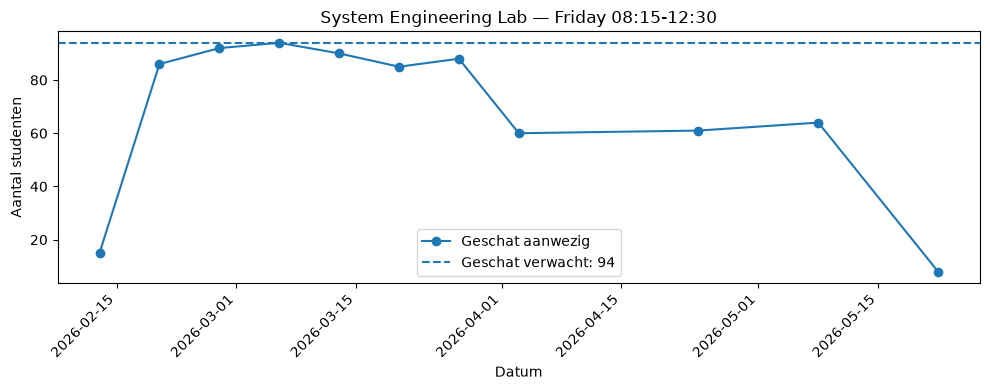

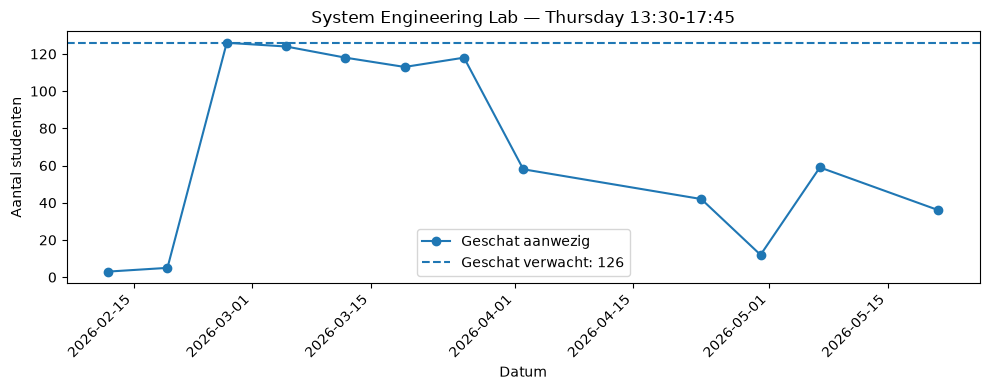

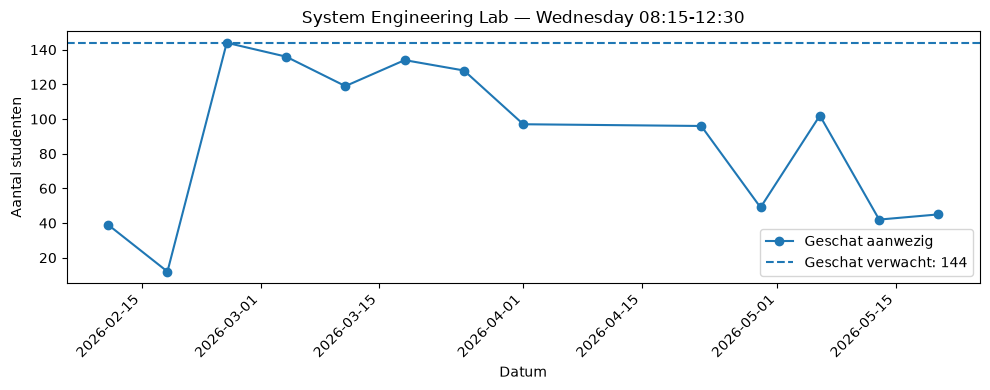

In [43]:
for session_slot, group in valid_sessions.groupby("SessionSlot"):
    group = group.sort_values("FullDate")

    plt.figure(figsize=(10, 4))

    plt.plot(
        group["FullDate"],
        group["EstimatedPresentStudents"],
        marker="o",
        label="Geschat aanwezig",
    )

    expected = group["ExpectedStudentsForSlot"].iloc[0]

    plt.axhline(
        expected,
        linestyle="--",
        label=f"Geschat verwacht: {expected}",
    )

    plt.xlabel("Datum")
    plt.ylabel("Aantal studenten")
    plt.title(
        f"System Engineering Lab — {session_slot}"
    )
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()


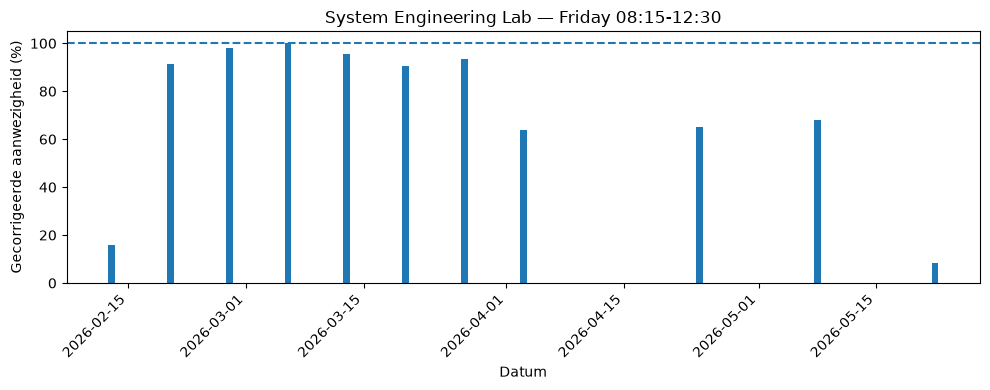

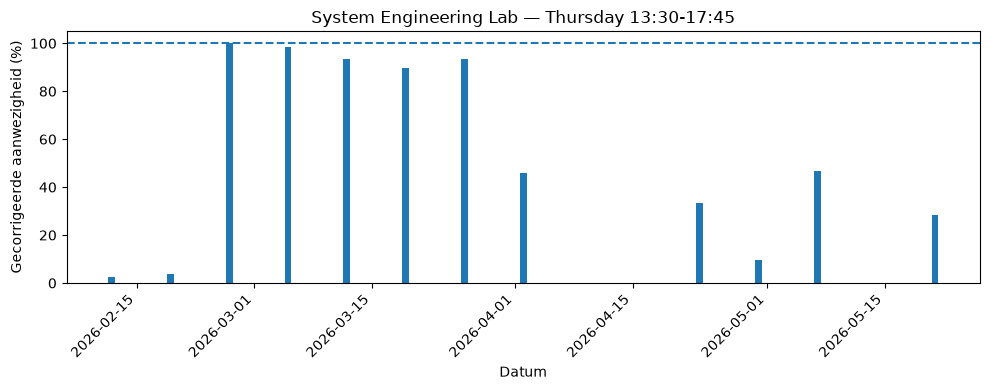

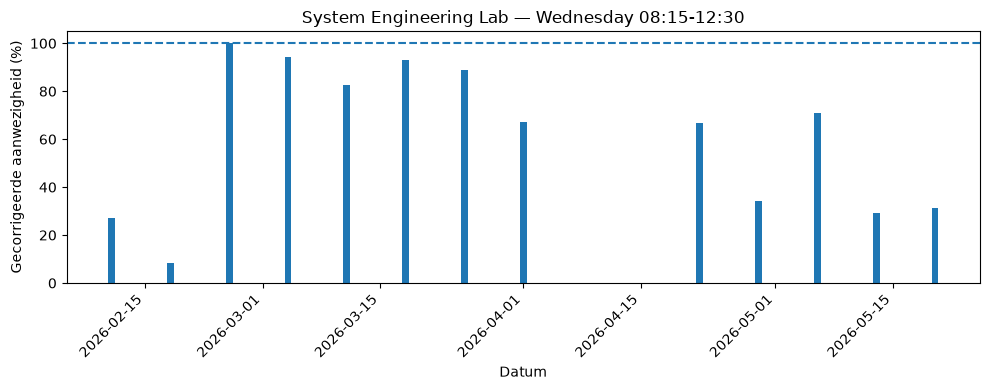

In [44]:
for session_slot, group in valid_sessions.groupby("SessionSlot"):
    group = group.sort_values("FullDate")

    plt.figure(figsize=(10, 4))

    plt.bar(
        group["FullDate"],
        group["CorrectedAttendanceRate"] * 100,
    )

    plt.axhline(100, linestyle="--")

    plt.xlabel("Datum")
    plt.ylabel("Gecorrigeerde aanwezigheid (%)")
    plt.title(
        f"System Engineering Lab — {session_slot}"
    )
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 17. Detail van de maxima per vast sessietype

In [45]:
maximum_session_ids = (
    valid_sessions.loc[
        valid_sessions.groupby("SessionSlot")[
            "EstimatedPresentStudents"
        ].idxmax(),
        "SessionID",
    ]
    .tolist()
)

maximum_details = (
    session_subgroup[
        session_subgroup["SessionID"].isin(
            maximum_session_ids
        )
    ]
    .sort_values([
        "FullDate",
        "SessionID",
        "SubgroupCode",
    ])
)

maximum_details


,FullDate,SessionID,SubgroupCode,EstimatedUniquePresent,AdministrativeStudents,NumberOfRows,NumberOfLectureIDs,NumberOfBlocks,NumberOfRooms,Rooms,MinBlockCount,MaxBlockCount
42,2026-02-25,20260225_1,PBA-TIN-TI/1A,25,32,2,2,2,1,01.02.140.037,6,25
43,2026-02-25,20260225_1,PBA-TIN-TI/1B,19,27,2,2,2,1,01.02.140.037,13,19
44,2026-02-25,20260225_1,PBA-TIN-TI/1C,27,33,2,2,2,1,01.02.140.037,27,27
45,2026-02-25,20260225_1,PBA-TIN-TI/1D,17,28,2,2,2,1,01.02.140.037,13,17
46,2026-02-25,20260225_1,PBA-TIN-TI/1E,8,27,2,2,2,1,01.02.140.037,7,8
47,2026-02-25,20260225_1,PBA-TIN-TI/1F,31,35,2,2,2,1,01.02.140.037,23,31
48,2026-02-25,20260225_1,PBA-TIN-TI/1G,17,27,2,2,2,1,01.02.140.037,15,17
49,2026-02-26,20260226_1,PBA-TIN-TI/1A,25,32,2,2,2,1,01.02.120.011,3,25
50,2026-02-26,20260226_1,PBA-TIN-TI/1B,16,27,2,2,2,1,01.02.120.011,3,16
51,2026-02-26,20260226_1,PBA-TIN-TI/1D,11,28,2,2,2,1,01.02.120.011,7,11


## 18. Administratief versus gecorrigeerd

In [46]:
comparison_summary = (
    valid_sessions
    .groupby("SessionSlot")
    .agg(
        MeanAdministrativeAttendance=(
            "AdministrativeAttendanceRate",
            "mean",
        ),
        MeanCorrectedAttendance=(
            "CorrectedAttendanceRate",
            "mean",
        ),
        MedianAdministrativeAttendance=(
            "AdministrativeAttendanceRate",
            "median",
        ),
        MedianCorrectedAttendance=(
            "CorrectedAttendanceRate",
            "median",
        ),
        ExpectedStudentsForSlot=(
            "ExpectedStudentsForSlot",
            "first",
        ),
    )
    .sort_index()
)

comparison_summary


,MeanAdministrativeAttendance,MeanCorrectedAttendance,MedianAdministrativeAttendance,MedianCorrectedAttendance,ExpectedStudentsForSlot
SessionSlot,,,,,
Friday 08:15-12:30,0.3311,0.7186,0.4167,0.9043,94
Thursday 13:30-17:45,0.3293,0.5384,0.2840,0.4643,126
Wednesday 08:15-12:30,0.4207,0.6106,0.4641,0.6736,144


## 19. Export

In [47]:
export_columns = [
    "FullDate",
    "SessionID",
    "SessionSlot",
    "SessionStart",
    "SessionEnd",
    "SessionDurationMinutes",
    "NumberOfTimeBlocks",
    "NumberOfSubgroups",
    "NumberOfDistinctRooms",
    "Rooms",
    "EstimatedPresentStudents",
    "ExpectedStudentsForSlot",
    "CorrectedAttendanceRate",
    "AdministrativeExpectedStudents",
    "AdministrativeAttendanceRate",
    "ISOYear",
    "ISOWeek",
    "YearWeek",
]

export_path = (
    "system_engineering_lab_corrected_sessions_by_slot.csv"
)

valid_sessions[export_columns].to_csv(
    export_path,
    index=False,
)

print(f"Export aangemaakt: {export_path}")


Export aangemaakt: system_engineering_lab_corrected_sessions_by_slot.csv


## Interpretatie

De correctie gebeurt nu niet langer met één globaal maximum voor het hele vak.

Elke vaste wekelijkse sessie heeft een eigen referentiewaarde:

- het maximum van woensdagvoormiddag geldt alleen voor woensdagvoormiddag;
- het maximum van woensdagnamiddag geldt alleen voor woensdagnamiddag;
- het maximum van een ander vast tijdslot geldt alleen voor dat tijdslot.

Aanbevolen formulering:

> Voor System Engineering Lab werden twee opeenvolgende roosterblokken samengevoegd tot één fysieke sessie. Omdat verschillende vaste sessiemomenten aan verschillende studentengroepen waren toegewezen, werd per combinatie van weekdag en sessietijd een aparte referentiewaarde bepaald. Het hoogste waargenomen aantal studenten binnen elk vast sessietype werd gebruikt als pragmatische schatting van het werkelijk verwachte aantal studenten voor dat sessietype.
